In [1]:

import os
import mat73
import torch
import numpy as np
import matplotlib.pyplot as plt
from slope2noise.utils import octave_filtering
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet
import DecayFitNet.python.toolbox.DecayFitNetToolbox as dfn

from slope2noise.utils import schroeder_backward_int
from slope2noise.dataclass import *
from slope2noise.generate import *


Load parameters from Georg's dataset 

In [ ]:
dataset_path = "/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/Common_Slope_Analysis_Results"
# load the impulse responses 
srirs = mat73.loadmat("/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/srirs.mat")['srirDataset']

In [74]:
f_bands = [125, 250, 500, 1000, 2000, 4000, 8000]
i_band = 4
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_"+str(f_bands[i_band])+".mat"
# read the mat file 
data = mat73.loadmat(os.path.join(dataset_path, filepath))['analysisResults']

# get the impulse responses
fs = srirs['fs'].item() # sampling frequnecy
L = srirs['srirs'].shape[1] # length of the impulse responses
loc_indx = 680   # location index [0, 838]
ref_rir = srirs['srirs'][loc_indx, :, 0]   # assuming that the omnidirectional is the first channel
time_axis = np.arange(0, L) / fs

Estimate the Decay parameters using DFN at 1000Hz 

In [75]:
# initialize the decay fit net toolbox
dfn_band = dfn.DecayFitNetToolbox(n_slopes=0, sample_rate=fs, filter_frequencies=[f_bands[i_band]])
# estimate the parameters 
estimated_param, norm_vals_decayfitnet = dfn_band.estimate_parameters(ref_rir, analyse_full_rir=True)
# fit the EDC
ref_edc_decayfitnet = decayfitnet.core.decay_model(torch.from_numpy(estimated_param[0]),
                                                    torch.from_numpy(estimated_param[1])*(norm_vals_decayfitnet.squeeze()),
                                                    torch.from_numpy(estimated_param[2])*(norm_vals_decayfitnet.squeeze()),
                                                    time_axis=torch.from_numpy(time_axis),
                                                    compensate_uli=True,
                                                    backend='torch')

Compare the estimated parameters with those in the dataset

In [76]:
# DecayFitNet finds the optimal number of slopes and set the rest to zero
valid_slopes =  np.nonzero(data['tVals_standard'][loc_indx, :])[0]
valid_slopes_dfn =  np.nonzero(estimated_param[1])[0]

isStandard = True
if isStandard: 
    t_vals = data['tVals_standard'][loc_indx, valid_slopes] 
    a_vals =  data['aVals_standard'][loc_indx, valid_slopes] 
    n_vals = data['nVals_standard'][loc_indx]
else: 
    t_vals = data['commonDecayTimes'] 
    a_vals =  data['aVals'][loc_indx, ...] 
    n_vals = data['nVals'][loc_indx]

In [77]:
print("dataset t_vals: ", t_vals)
print("estimated t_vals: ", estimated_param[0].squeeze()[valid_slopes_dfn])

print("a_vals: ", a_vals)
print("estimated a_vals: ", estimated_param[1].squeeze()[valid_slopes_dfn])

print("n_vals: ", n_vals)
print("estimated n_vals: ", estimated_param[2].squeeze())


dataset t_vals:  [1.55049969 3.39127965]
estimated t_vals:  [1.2693211 1.2693211]
a_vals:  [9.1861652  0.22181303]
estimated a_vals:  [0.937201 0.937201]
n_vals:  3.6536130910184174e-09
estimated n_vals:  3.400021e-17


Compare the EDC from SRIR filtered at 1000 with the fitted EDC

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_6114/1099015921.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(time_axis, 10*np.log10(ref_edc_decayfitnet.squeeze()), '-.', label='EDC fitted on Decay Fit Net estimations')


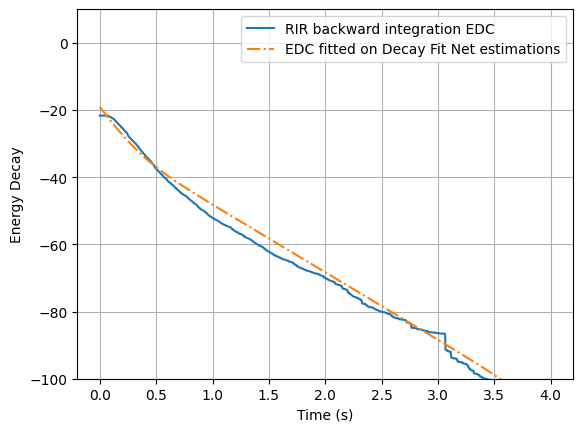

In [78]:
# extract the 1000 Hz band from the impulse response
ref_rir_filt = octave_filtering(ref_rir, fs, f_bands, compensate_filter_energy=False)[:, i_band]
# Use schroeder backward integration to estimate the EDC
ref_filt_int = schroeder_backward_int(ref_rir_filt.squeeze(), normalize=False)

plt.plot(time_axis, 10*np.log10(ref_filt_int), '-', label='RIR backward integration EDC')
plt.plot(time_axis, 10*np.log10(ref_edc_decayfitnet.squeeze()), '-.', label='EDC fitted on Decay Fit Net estimations')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()

